# Implementation of basic NEAT algorithm.

In [1]:
import numpy as np
import networkx as nx
from __future__ import annotations
import copy

In [2]:
from dataclasses import dataclass
from typing import Callable

def neat_tanh(W, x):
    return np.tanh(W @ x)

# NEAT steepened sigmoid
def neat_sigmoid(W, x):
    return 1 / (1 + np.exp(np.clip(-4.9 * (W @ x), -500, 500)))

@dataclass
class GenomeConfig:
    cross_p_inherit_weaker: float = 0.5
    cross_p_stay_disabled: float = 0.75
    mut_p_add_node: float = 0.3
    mut_p_add_link: float = 0.2
    mut_p_replace: float = 0.1 # 1 - p_replace = p_pertubate
    mut_pertubation_range: float = 2.0
    mut_max_weight: float = 8.0
    mut_min_weight: float = -8.0
    mut_clip_weights: bool = True
    activation_fun: Callable = neat_tanh

In [3]:
from enum import Enum

class NodeType(Enum):
    INPUT = 0
    OUTPUT = 1
    HIDDEN = 2

class Individual:
    """
    Represents one solution/network/genome/individual.
    """
    def __init__(self, config:GenomeConfig=None):
        self.config = config if config else GenomeConfig()
        self.network = nx.DiGraph()
        self.fitness = 0

    def add_node_gene(self, node_id: int, node_type: NodeType):
        self.network.add_node(node_id, type=node_type)

    def add_connection_gene(self, in_node: int, out_node: int, innov: int, weight: float, enabled: bool):
        self.network.add_edge(in_node, out_node, innov=innov, weight=weight, enabled=enabled)

    def size(self) -> int:
        return self.network.number_of_nodes() + self.network.number_of_edges()

    def clone(self) -> Individual:
        child = Individual()
        child.config = self.config
        child.network = self.network.copy()
        child.compile_network()
        return child

    def _get_innov_dict(self):
        """Helper to get O(1) innovation lookups for crossover/distance."""
        return {attr['innov']: (u, v, attr) 
                for u, v, attr in self.network.edges(data=True)}

    def distance(self, other: Individual, c1=1.0, c2=0.4) -> float:
        """
        Compute *Compatibiliy Distance*, ignore node genes and the distiction between excess and disjoint genes.
        """
        genes_self, genes_other = self._get_innov_dict(), other._get_innov_dict()
        innov_self, innov_other = set(genes_self.keys()), set(genes_other.keys())
        
        matching_keys = innov_self & innov_other
        non_homologous_count = len(innov_self ^ innov_other)

        if matching_keys:
            w1 = np.array([genes_self[k][2]['weight'] for k in matching_keys])
            w2 = np.array([genes_other[k][2]['weight'] for k in matching_keys])
            weight_diff = np.mean(np.abs(w1 - w2))
        else:
            weight_diff = 0.0
    
        N = max(len(innov_self), len(innov_other))

        return (c1 * non_homologous_count / N) + (c2 * weight_diff)

    def crossover(self, other: Individual) -> Individual:
        """
        Innovation number aligned crossover with tunable inheritance probabilities.
        """
        child = Individual()
        fitter, weaker = (self, other) if self.fitness >= other.fitness else (other, self)

        genes_fitter, genes_weaker = fitter._get_innov_dict(), weaker._get_innov_dict()

        child.network.add_nodes_from(fitter.network.nodes(data=True))

        for innov_num, (u, v, attr) in genes_fitter.items():
            child_attr = copy.deepcopy(attr)

            if innov_num in genes_weaker:
                weaker_attr = genes_weaker[innov_num][2]
                
                if np.random.random() < self.config.cross_p_inherit_weaker:
                    child_attr['weight'] = weaker_attr['weight']
                    
                if not attr['enabled'] or not weaker_attr['enabled']:
                    child_attr['enabled'] = np.random.random() > self.config.cross_p_stay_disabled 
                    
            child.network.add_edge(u, v, **child_attr)
        
        return child

    def mutate_weights(self):
        edges = list(self.network.edges(data=True))
        n_edges = len(edges)
        
        replacements = np.random.uniform(self.config.mut_min_weight, self.config.mut_max_weight, n_edges)
        perturbations = np.random.uniform(-self.config.mut_pertubation_range, self.config.mut_pertubation_range, n_edges)
        action_probs = np.random.rand(n_edges)
    
        for i, (u, v, attr) in enumerate(edges):
            if action_probs[i] < self.config.mut_p_replace:
                attr['weight'] = replacements[i]
            else:
                attr['weight'] += perturbations[i]
                if self.config.mut_clip_weights:
                    attr['weight'] = max(self.config.mut_min_weight, min(self.config.mut_max_weight, attr['weight']))

    def mutate_genes(self, get_link_innovation: Callable, get_node_innovation: Callable):
        if np.random.random() < self.config.mut_p_add_link:
            nodes = list(self.network.nodes(data=True))
            
            in_node, in_attr = nodes[np.random.choice(len(nodes))]
            out_node, out_attr = nodes[np.random.choice(len(nodes))]
            
            is_valid_type = in_attr['type'] != NodeType.OUTPUT and out_attr['type'] != NodeType.INPUT
            is_new = not self.network.has_edge(in_node, out_node)
            is_not_loop = in_node != out_node
            is_not_looping = not nx.has_path(self.network, out_node, in_node)
            
            if is_valid_type and is_not_loop and is_new and is_not_looping:
                self.add_connection_gene(
                    in_node, out_node,
                    innov=get_link_innovation(in_node, out_node),
                    weight=np.random.uniform(self.config.mut_min_weight, self.config.mut_max_weight),
                    enabled=True
                )
        
        if np.random.random() < self.config.mut_p_add_node:
            # only hidden nodes are added
            # split: N_1 -> N_2 to N_1 -> N_new -> N_2
            enabled_edges = [(u, v, attr) for u, v, attr in self.network.edges(data=True) if attr['enabled']]
            if not enabled_edges:
                return
            
            n_1, n_2, current_attr = enabled_edges[np.random.choice(len(enabled_edges))]
            
            current_attr['enabled'] = False
            
            new_node_id = get_node_innovation(current_attr['innov'])
            self.add_node_gene(new_node_id, NodeType.HIDDEN)
            
            self.add_connection_gene(
                in_node=n_1, out_node=new_node_id,
                innov=get_link_innovation(n_1, new_node_id),
                weight=1.0, enabled=True
            )
            self.add_connection_gene(
                in_node=new_node_id, out_node=n_2,
                innov=get_link_innovation(new_node_id, n_2),
                weight=current_attr['weight'], enabled=True
            )

    def compile_network(self):
        """
        Compile network into adjacency matrix of weights between nodes.
        Store meta information for forward pass in _members.
        """
        self._node_idx_map = {key: i for i, key in enumerate(self.network.nodes())}
        n_nodes = len(self._node_idx_map)
        self._W = np.zeros((n_nodes, n_nodes))

        # used in forward_pass input/output
        self._input_indices = [
            self._node_idx_map[n] for n, attr in self.network.nodes(data=True) 
            if attr['type'] == NodeType.INPUT
        ]
        self._output_indices = [
            self._node_idx_map[n] for n, attr in self.network.nodes(data=True) 
            if attr['type'] == NodeType.OUTPUT
        ]
        
        for u, v, attr in self.network.edges(data=True):
            if attr['enabled']:
                u_idx, v_idx = self._node_idx_map[u], self._node_idx_map[v]
                self._W[v_idx][u_idx] = attr['weight']

        self._network_depth = nx.dag_longest_path_length(self.network, weight=None) + 1
    
    def forward_pass(self, inputs: np.ndarray) -> np.ndarray:
        if len(inputs) != len(self._input_indices):
            raise ValueError("Number of input nodes doesn't match")
        
        state = np.zeros(len(self._node_idx_map))
        state[:len(inputs)] = inputs 
        
        for _ in range(self._network_depth):
            new_state = self.config.activation_fun(self._W, state)
            new_state[:len(inputs)] = inputs
            state = new_state
        
        return state[self._output_indices]

In [4]:
@dataclass
class PopulationConfig:
    dropoff_age: int = 10
    p_selection: float = 0.2
    p_mutation_without_cross: float = 0.3
    p_interspecies_mate: float = 0.001
    n_min_elite_survival: int = 3
    use_random_representatives: bool = True

In [5]:
from concurrent.futures import ProcessPoolExecutor
from collections import Counter, defaultdict

class Population:
    """
    This class applies the NEAT speciation and NeuroEvolution loop (fitness_evalution, selection, crossover, mutation)
    to a population of Individuals.
    """
    def __init__(self, size:int, compatibility_threshold: float, cluster_species_func: Callable):
        self.config = PopulationConfig()
        self.size = size
        self.individuals = []
        self.cluster_species_func = cluster_species_func
        # track global innovation numbers for shared genes
        self.population_counter = {'innov':0, 'node':0}
        self.current_generation_innovations = {}
        # tracking drop-off age
        self.species_history = defaultdict(lambda: {'max_fitness': -float('inf'), 'stagnant_gens': 0})
        # track representatives for clustering in next generation
        self.previous_representatives = {}
        self.compatibility_threshold = compatibility_threshold

    def _get_link_innovation(self, in_node: int, out_node: int) -> int:
        key = ('link', in_node, out_node)
        if key not in self.current_generation_innovations:
            self.population_counter['innov'] += 1
            self.current_generation_innovations[key] = self.population_counter['innov']
        return self.current_generation_innovations[key]

    def _get_node_innovation(self, link_to_split: int) -> int:
        key = ('node', link_to_split)
        if key not in self.current_generation_innovations:
            self.population_counter['node'] += 1
            self.current_generation_innovations[key] = self.population_counter['node']
        return self.current_generation_innovations[key]

    def reset_generation_innovations(self):
        self.current_generation_innovations.clear()

    def select_reproduce_mutate(self):
        report = {}
        # 1. Cluster and Allocations
        clusters = self.cluster_species_func(self.individuals, self.previous_representatives, self.compatibility_threshold)
        n_per_cluster = Counter(clusters)
        
        fitnesses = np.array([max(0.0001, ind.fitness) for ind in self.individuals]) # Prevent zero/negative math errors
        shared_fitnesses = fitnesses / np.array([n_per_cluster[c] for c in clusters])

        # Sum fitness per cluster and enforce dropoff age
        report['species'] = {}
        fitness_per_cluster = {}
        for cluster in set(clusters):
            cluster_inds = [ind for ind, c in zip(self.individuals, clusters) if c == cluster]
            max_fit = max(ind.fitness for ind in cluster_inds)
            
            report['species'][cluster] = [ind.fitness for ind in cluster_inds]
            
            history = self.species_history[cluster]
            if max_fit > history['max_fitness']:
                history['max_fitness'] = max_fit
                history['stagnant_gens'] = 0
            else:
                history['stagnant_gens'] += 1
                
            is_stagnant = history['stagnant_gens'] >= self.config.dropoff_age
            is_best_species = max(ind.fitness for ind in self.individuals) == max_fit
            
            if is_stagnant and not is_best_species:
                fitness_per_cluster[cluster] = 0.0001
            else:
                fitness_per_cluster[cluster] = sum(shared_fitnesses[np.array(clusters) == cluster])

        report['sharedfitness_per_cluster'] = fitness_per_cluster

        # Offspring Allocation
        total_adjusted_fitness = sum(fitness_per_cluster.values())
        allocation_per_cluster = {
            c: int((fit / total_adjusted_fitness) * self.size) 
            for c, fit in fitness_per_cluster.items()
        }
        
        # Handle rounding errors
        missing_allocations = self.size - sum(allocation_per_cluster.values())
        if missing_allocations > 0:
            best_cluster = max(fitness_per_cluster, key=fitness_per_cluster.get)
            allocation_per_cluster[best_cluster] += missing_allocations
        
        report['allocations'] = allocation_per_cluster

        # 2. Reproduction and Mutation
        next_generation_individuals = []
        all_survivors = []
        cluster_survivor_map = {}
        
        for cluster in set(clusters):
            cluster_inds = [ind for ind, c in zip(self.individuals, clusters) if c == cluster]
            cluster_inds.sort(key=lambda ind: ind.fitness, reverse=True)
            n_survivors = max(1, int(len(cluster_inds) * self.config.p_selection))
            
            survivors = cluster_inds[:n_survivors]
            cluster_survivor_map[cluster] = survivors
            all_survivors.extend(survivors)

        for cluster, allocation in allocation_per_cluster.items():
            if allocation == 0:
                continue
                
            survivors = cluster_survivor_map[cluster]
            offspring_count = 0
            
            # Elite survival
            if len(survivors) >= self.config.n_min_elite_survival:
                next_generation_individuals.append(survivors[0].clone())
                offspring_count += 1

            while offspring_count < allocation:
                if np.random.random() < self.config.p_mutation_without_cross:
                    # Clone and Mutate
                    parent = np.random.choice(survivors)
                    child = parent.clone()
                else:
                    # Crossover
                    parent1, parent2 = np.random.choice(survivors, 2)
                    
                    # INTERSPECIES MATING
                    if np.random.random() < self.config.p_interspecies_mate:
                        parent2 = np.random.choice(all_survivors)
                        
                    child = parent1.crossover(parent2)

                child.mutate_weights()
                child.mutate_genes(self._get_link_innovation, self._get_node_innovation)
                child.compile_network()
                
                next_generation_individuals.append(child)
                offspring_count += 1

        # Update representatives for next generation clustering
        self.previous_representatives.clear()
        for cluster in set(clusters):
            survivors = cluster_survivor_map.get(cluster, [])
            if not survivors:
                continue # Species went extinct
                
            if self.config.use_random_representatives:
                self.previous_representatives[cluster] = np.random.choice(survivors)
            else:
                self.previous_representatives[cluster] = survivors[0]

        self.individuals = next_generation_individuals
        self.reset_generation_innovations()

        return report


In [6]:
# split evalute_fitness for readability
class Population(Population):
    def evaluate_fitness(self, vector_env, action_mapper=None, max_steps=1000, n_runs=3):
        """
        Evaluates the population concurrently using a Gymnasium VectorEnv.
        Runs each agent 'n_runs' times and averages their fitness.
        """
        if vector_env.num_envs != self.size:
            raise ValueError(f"VectorEnv must have exactly {self.size} environments to match population size.")
        
        total_fitness_scores = np.zeros(self.size, dtype=float)

        for run in range(n_runs):
            obs, info = vector_env.reset()
            
            finished = np.zeros(self.size, dtype=bool)
            current_run_scores = np.zeros(self.size, dtype=float)

            for _ in range(max_steps):
                if finished.all():
                    break

                actions = []
                for i, ind in enumerate(self.individuals):
                    if not finished[i]:
                        raw_action = ind.forward_pass(obs[i])
                        action = action_mapper(raw_action) if action_mapper else raw_action
                        actions.append(action)
                    else:
                        # dummy action
                        actions.append(vector_env.single_action_space.sample())
                
                obs, rewards, terminated, truncated, infos = vector_env.step(np.array(actions))

                dones = terminated | truncated
                current_run_scores += rewards * (~finished)
                finished = finished | dones

            total_fitness_scores += current_run_scores

        avg_fitness_scores = total_fitness_scores / n_runs

        for ind, fit in zip(self.individuals, avg_fitness_scores):
            ind.fitness = fit

In [7]:
# TODO make class function
def create_population(size: int, n_inputs: int, n_outputs: int, compatibility_threshold:float, cluster_func: callable) -> Population:
    """
    Initializes a NEAT population with minimal, fully-connected networks.
    Inputs are connected to all outputs with random weights.
    """
    pop = Population(size=size, compatibility_threshold=compatibility_threshold, cluster_species_func=cluster_func)
    pop.population_counter['node'] = n_inputs + n_outputs - 1
    
    for _ in range(size):
        ind = Individual()
        
        # I/O Nodes
        for i in range(n_inputs):
            ind.add_node_gene(node_id=i, node_type=NodeType.INPUT)
        for j in range(n_outputs):
            out_node_id = n_inputs + j
            ind.add_node_gene(node_id=out_node_id, node_type=NodeType.OUTPUT)
            
        # Connections
        for in_node in range(n_inputs):
            for j in range(n_outputs):
                out_node = n_inputs + j
                
                innov_num = pop._get_link_innovation(in_node, out_node)
                
                weight = np.random.uniform(
                    ind.config.mut_min_weight, 
                    ind.config.mut_max_weight
                )
                
                ind.add_connection_gene(
                    in_node=in_node,
                    out_node=out_node,
                    innov=innov_num,
                    weight=weight,
                    enabled=True
                )
        
        ind.compile_network()
        pop.individuals.append(ind)
        
    pop.reset_generation_innovations()
    
    return pop

In [8]:
def cluster_species(individuals: list, previous_representatives: dict, compatibility_threshold: float = 3.0) -> list:
    """
    Greedy sequential clustering.
    """
    representatives = previous_representatives.copy() 
    clusters = []

    next_cluster_id = max(representatives.keys()) + 1 if representatives else 0
    
    for ind in individuals:
        assigned_cluster = None

        for cluster_id, rep in representatives.items():
            if ind.distance(rep) < compatibility_threshold:
                assigned_cluster = cluster_id
                break 
                
        if assigned_cluster is None:
            assigned_cluster = next_cluster_id
            representatives[next_cluster_id] = ind 
            next_cluster_id += 1
            
        clusters.append(assigned_cluster)
        
    return clusters

In [9]:
def train_NEAT(gym_env_func: Callable, action_mapper: Callable, max_steps:int, n_runs:int, max_iterations:int, population_size:int, compatibility_threshold:float, n_target_species=0):
    best_individual = None
    sample_env = gym_env_func()
    n_inputs = sample_env.observation_space.shape[0]

    if isinstance(sample_env.action_space, gym.spaces.Discrete):
        n_outputs = sample_env.action_space.n
    else:
        n_outputs = sample_env.action_space.shape[0]

    # SyncVectorEnv runs all envs in-process. For these lightweight envs it is much
    # faster than AsyncVectorEnv, which spawns one subprocess per individual and pays
    # heavy per-step pickling/IPC overhead that dominates the (single-threaded) work.
    envs = gym.vector.SyncVectorEnv(
        [lambda: gym_env_func() for _ in range(population_size)]
    )
    population = create_population(
        size=population_size, 
        n_inputs=n_inputs, 
        n_outputs=n_outputs,
        compatibility_threshold=compatibility_threshold,
        cluster_func=cluster_species # hidden dependency
    )

    report = []

    for i in range(max_iterations):
        population.evaluate_fitness(
            vector_env=envs, 
            action_mapper=action_mapper, 
            max_steps=max_steps,
            n_runs=n_runs,
        )
        population.individuals.sort(key=lambda ind: ind.fitness, reverse=True)
        print(f"Generation [{i:02}] best fitness:{population.individuals[0].fitness:4.3f}, current threshold:{population.compatibility_threshold:2.3f}, ", end='')
        
        if best_individual is None or population.individuals[0].fitness > best_individual.fitness:
            best_individual = population.individuals[0].clone()

        population_report = population.select_reproduce_mutate()
        population_report['generation'] = i
        report.append(population_report)

        current_species_count = len(population_report['species'])

        print(f"N species = {current_species_count}")

        # Adaptive Threshold
        if n_target_species == 0:
            continue
        
        THRESHOLD_MODIFIER = 0.3
        #population.compatibility_threshold += (np.sign(current_species_count - target_species) * THRESHOLD_MODIFIER)
        if current_species_count > n_target_species:
            population.compatibility_threshold *= 1.05
        elif current_species_count < n_target_species:
            population.compatibility_threshold *= 0.95
        
        # Guard against threshold dropping below an unusable level
        MIN_THRESHOLD = 0.5
        if population.compatibility_threshold < MIN_THRESHOLD:
            population.compatibility_threshold = MIN_THRESHOLD

    envs.close()
    return best_individual, report

# Running NEAT in gymnasium
Note: when running CartPole or LunarLander use argmax and sigmoid activation function, for BipedalWalker use tanh (maybe sin) and contious action mapper.

Try changing the compatibility_threshold to determine speciation.

In [10]:
import gymnasium as gym

In [11]:
import time

def watch_agent(model, render_env, action_mapper):
    state, _ = render_env.reset()
    done = False
    reward, steps = 0, 0
    
    while not done:
        output = model.forward_pass(state)
        action = action_mapper(output)
    
        next_state, reward, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
        state = next_state
        reward += reward
        steps += 1
        time.sleep(0.005)

    print("Achieved", reward, "over", steps, "steps")
    render_env.close()

In [12]:
import pickle
import os

def save_individual(individual, filename="neat_model.pkl"):
    """
    Serializes and saves a NEAT Individual (genome and compiled weights) to disk.
    """
    # Ensure the directory exists if a path is provided
    dir_name = os.path.dirname(filename)
    if dir_name and not os.path.exists(dir_name):
        os.makedirs(dir_name)
        
    with open(filename, 'wb') as f:
        pickle.dump(individual, f)
    print(f" Successfully saved model to: {filename}")

def load_individual(filename="neat_model.pkl"):
    """
    Loads and re-verifies a saved NEAT Individual from disk.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"No saved model found at {filename}")
        
    with open(filename, 'rb') as f:
        individual = pickle.load(f)
        
    # Re-run compile just to verify internal structural maps (_W, _node_idx_map) 
    # are aligned and completely healthy after deserialization
    individual.compile_network()
    
    print(f" Successfully loaded model from: {filename}")
    return individual

In [13]:
def argmax_action_mapper(network_output):
    return np.argmax(network_output)

## CartPole

In [14]:
make_cartpole_gym_env = lambda : gym.make("CartPole-v1")

best_cartpole_model, report = train_NEAT(
    gym_env_func=make_cartpole_gym_env,
    action_mapper=argmax_action_mapper,
    max_steps=500,
    n_runs=2,
    max_iterations=2,
    population_size=100,
    compatibility_threshold=3.0
)

Generation [00] best fitness:500.000, current threshold:3.000, N species = 2
Generation [01] best fitness:500.000, current threshold:3.000, N species = 1


In [16]:
save_individual(best_cartpole_model, filename="best_cartpole_model.pkl")

 Successfully saved model to: best_cartpole_model.pkl


In [15]:
watch_agent(
    model=best_cartpole_model,
    render_env=gym.make('CartPole-v1', render_mode="human"),
    action_mapper=argmax_action_mapper,
)

Achieved 2.0 over 500 steps


## Lunar Lander
Note: the agent often doesn't stop, maybe increase pentalty for taking to long?

In [17]:
make_lunar_env = lambda: gym.make('LunarLander-v3')

best_lunar_model, report = train_NEAT(
    gym_env_func=make_lunar_env,
    action_mapper=argmax_action_mapper,
    max_steps=1000,
    n_runs=3,
    max_iterations=50,
    population_size=150,
    compatibility_threshold=1.8,
    n_target_species=10,
)

Generation [00] best fitness:-48.130, current threshold:1.800, N species = 34
Generation [01] best fitness:-27.934, current threshold:1.890, N species = 30
Generation [02] best fitness:7.493, current threshold:1.985, N species = 23
Generation [03] best fitness:78.449, current threshold:2.084, N species = 7
Generation [04] best fitness:142.584, current threshold:1.980, N species = 1
Generation [05] best fitness:50.531, current threshold:1.881, N species = 1
Generation [06] best fitness:59.934, current threshold:1.787, N species = 5
Generation [07] best fitness:39.561, current threshold:1.697, N species = 14
Generation [08] best fitness:82.193, current threshold:1.782, N species = 13
Generation [09] best fitness:169.320, current threshold:1.871, N species = 6
Generation [10] best fitness:194.011, current threshold:1.778, N species = 13
Generation [11] best fitness:182.250, current threshold:1.866, N species = 10
Generation [12] best fitness:128.420, current threshold:1.866, N species = 8

In [20]:
save_individual(best_lunar_model, filename="best_lunar_model.pkl")

 Successfully saved model to: best_lunar_model.pkl


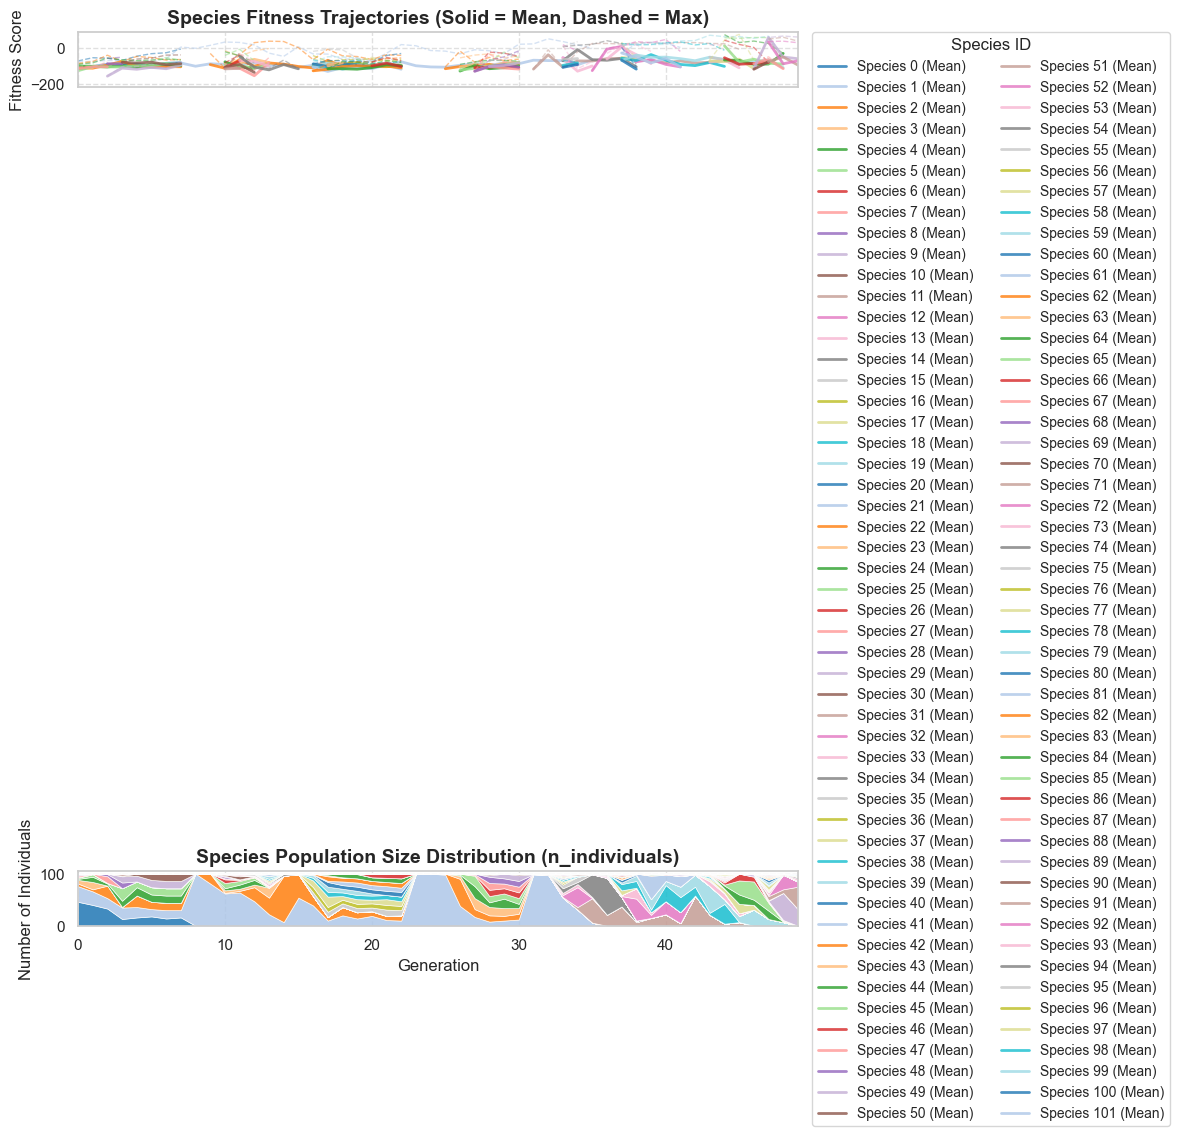

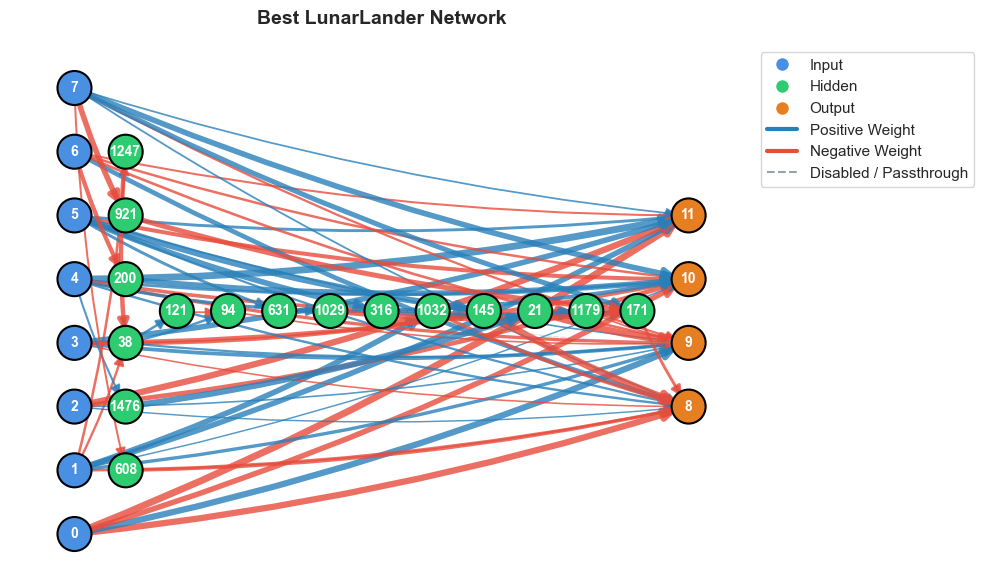

In [25]:
visualize_species_evolution(report)
visualize_network(best_lunar_model, title="Best LunarLander Network")
plt.tight_layout()
plt.show()

In [26]:
watch_agent(
    model=best_lunar_model,
    render_env=gym.make('LunarLander-v3', render_mode="human"),
    action_mapper=argmax_action_mapper,
)

Achieved 200 over 322 steps


## Bipedal Walker

In [27]:
# switch activation function from sigmoid [0, 1] to tanh [-1, 1]
def continuous_action_mapper(network_output):
    return np.array(network_output)

In [19]:
make_bipedal_env = lambda: gym.make('BipedalWalker-v3')

best_bipedal_model, report = train_NEAT(
    gym_env_func=make_bipedal_env,
    action_mapper=continuous_action_mapper, 
    max_steps=800,
    n_runs=1,
    max_iterations=50,
    population_size=100,
    compatibility_threshold=2.1,
    n_target_species=10,
)

Generation [00] best fitness:-72.009, current threshold:2.100, N species = 11
Generation [01] best fitness:-54.480, current threshold:2.205, N species = 7
Generation [02] best fitness:-40.849, current threshold:2.095, N species = 8
Generation [03] best fitness:-51.780, current threshold:1.990, N species = 9
Generation [04] best fitness:-46.079, current threshold:1.891, N species = 7
Generation [05] best fitness:-32.396, current threshold:1.796, N species = 7
Generation [06] best fitness:-27.386, current threshold:1.706, N species = 7
Generation [07] best fitness:3.530, current threshold:1.621, N species = 7
Generation [08] best fitness:-2.816, current threshold:1.540, N species = 1
Generation [09] best fitness:13.110, current threshold:1.463, N species = 2
Generation [10] best fitness:31.133, current threshold:1.390, N species = 12
Generation [11] best fitness:28.919, current threshold:1.459, N species = 11
Generation [12] best fitness:28.007, current threshold:1.532, N species = 10
Ge

In [21]:
save_individual(best_bipedal_model, "best_bipedal_model.pkl")

 Successfully saved model to: best_bipedal_model.pkl


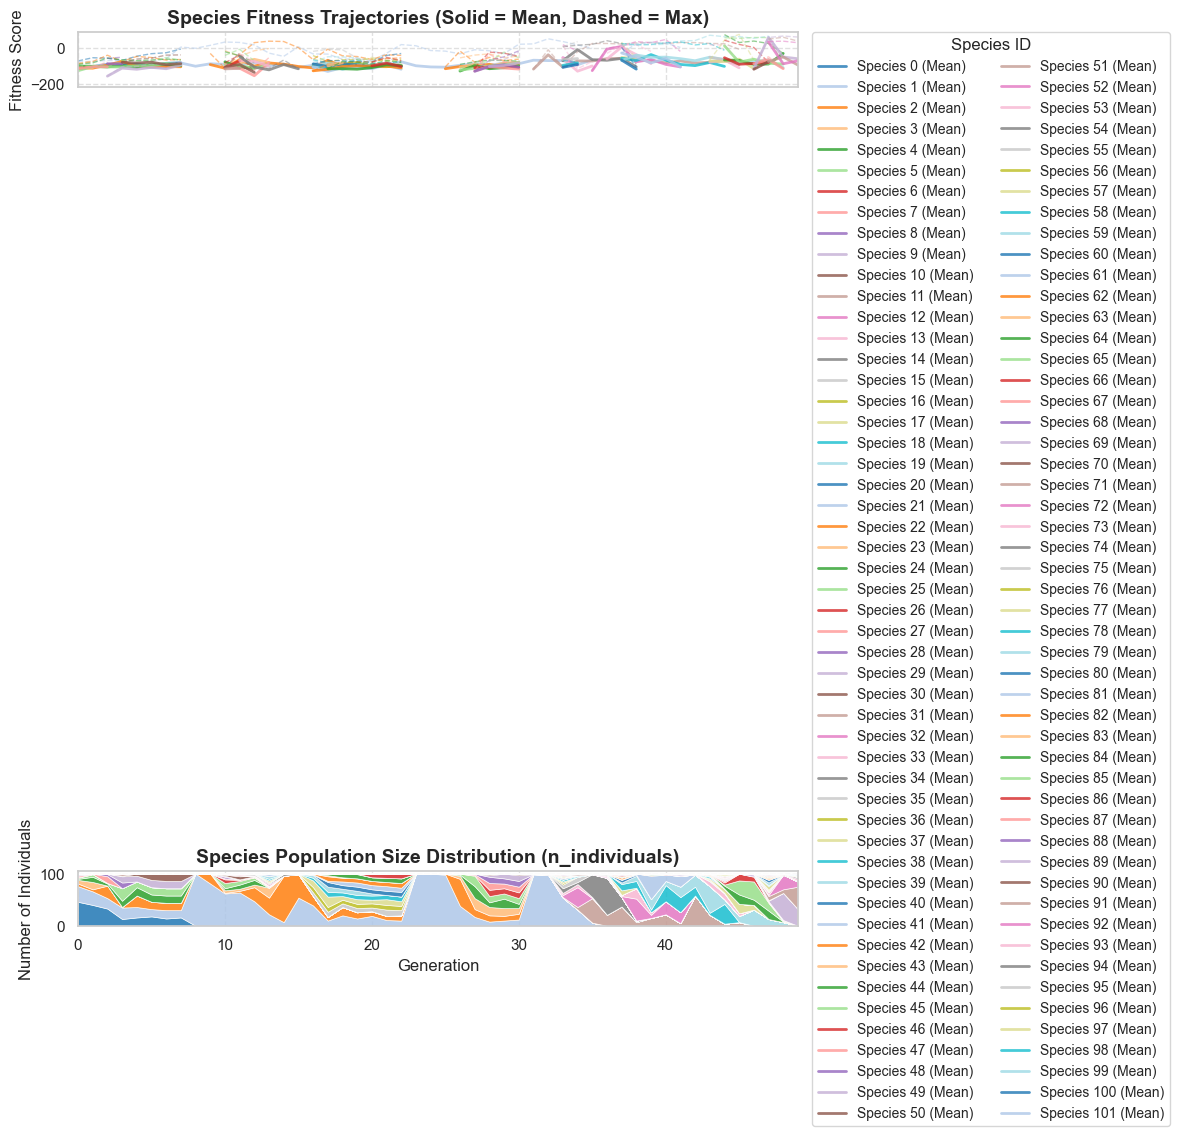

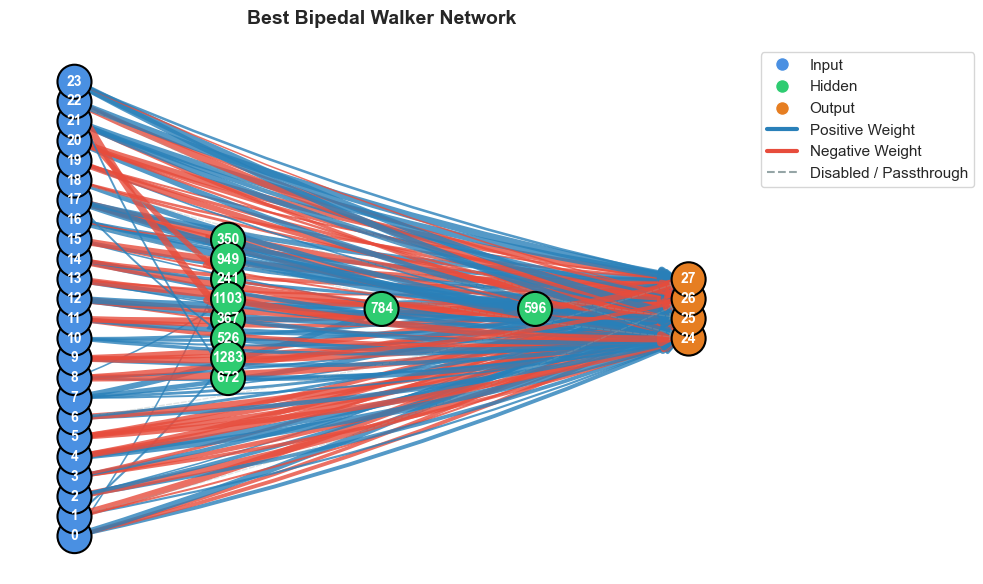

In [28]:
visualize_species_evolution(report)
visualize_network(best_bipedal_model, title="Best Bipedal Walker Network")
plt.tight_layout()
plt.show()

In [29]:
watch_agent(
    model=best_bipedal_model,
    render_env=gym.make('BipedalWalker-v3', render_mode="human"),
    action_mapper=continuous_action_mapper,
)

Achieved 0.3259833182091504 over 1600 steps


# Visualization Functions

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def visualize_species_evolution(report):
    """
    Parses the NEAT training report to visualize species fitness and population size dynamics.
    """
    # Set styling
    sns.set_theme(style="whitegrid")
    num_generations = len(report)
    generations = np.arange(num_generations)
    
    # 1. Identify all unique species IDs that existed at any point during training
    all_species_ids = sorted(list({
        s_id for gen_data in report for s_id in gen_data['species'].keys()
    }))
    
    # 2. Build tracking arrays for each species
    mean_fitness_matrix = np.full((len(all_species_ids), num_generations), np.nan)
    max_fitness_matrix = np.full((len(all_species_ids), num_generations), np.nan)
    size_matrix = np.zeros((len(all_species_ids), num_generations))
    
    species_idx_map = {s_id: i for i, s_id in enumerate(all_species_ids)}
    
    # 3. Populate matrices from the report
    for gen_idx, gen_data in enumerate(report):
        for s_id, fitnesses in gen_data['species'].items():
            idx = species_idx_map[s_id]
            size_matrix[idx, gen_idx] = len(fitnesses)
            if len(fitnesses) > 0:
                mean_fitness_matrix[idx, gen_idx] = np.mean(fitnesses)
                max_fitness_matrix[idx, gen_idx] = np.max(fitnesses)

    # 4. Create the figure with two subplots sharing the x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Generate a distinct color palette for the species
    palette = sns.color_palette("tab20", n_colors=len(all_species_ids))
    
    # --- Subplot 1: Species Fitness Over Generations ---
    for i, s_id in enumerate(all_species_ids):
        if np.any(~np.isnan(mean_fitness_matrix[i])):
            ax1.plot(generations, mean_fitness_matrix[i], label=f"Species {s_id} (Mean)", 
                     color=palette[i], linewidth=2, alpha=0.8)
            ax1.plot(generations, max_fitness_matrix[i], color=palette[i], 
                     linestyle="--", linewidth=1, alpha=0.5)
            
    ax1.set_title("Species Fitness Trajectories (Solid = Mean, Dashed = Max)", fontsize=14, fontweight="bold")
    ax1.set_ylabel("Fitness Score", fontsize=12)
    
    # FIXED: Replaced invalid 'max_lines' with 'ncol' and adjusted font size for large legend lists
    num_columns = 2 if len(all_species_ids) > 10 else 1
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, 
               title="Species ID", ncol=num_columns, fontsize="small", title_fontsize="medium")
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # --- Subplot 2: Species Population Size (Stacked Area Chart) ---
    ax2.stackplot(generations, size_matrix, labels=[f"Species {s_id}" for s_id in all_species_ids], 
                  colors=palette, alpha=0.85, edgecolor="white", linewidth=0.5)
    
    ax2.set_title("Species Population Size Distribution (n_individuals)", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Generation", fontsize=12)
    ax2.set_ylabel("Number of Individuals", fontsize=12)
    ax2.set_xlim(0, max(1, num_generations - 1))
    ax2.grid(True, linestyle="--", alpha=0.6)
    
    # Adjust layout to accommodate the external legend
    plt.tight_layout()
    plt.show()

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np

def visualize_network(individual, title="NEAT Network Topology", ax=None):
    """
    Visualizes an Individual's NetworkX graph with inputs on the left, 
    outputs on the right, and hidden nodes layered by depth.
    
    Weights are mapped to line thickness and color (red=negative, blue=positive).
    Disabled edges are drawn as faded dashed lines.
    """
    G = individual.network
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Assign layers for multipartite positioning
    # Identify node categories
    inputs = [n for n, attr in G.nodes(data=True) if attr.get('type') == NodeType.INPUT]
    outputs = [n for n, attr in G.nodes(data=True) if attr.get('type') == NodeType.OUTPUT]
    hiddens = [n for n, attr in G.nodes(data=True) if attr.get('type') == NodeType.HIDDEN]
    
    # Calculate depth for hidden nodes based on longest path from any input
    node_layers = {}
    for n in inputs:
        node_layers[n] = 0
        
    for n in hiddens:
        # Find maximum path length from any input node to this hidden node
        max_dist = 1
        for inp in inputs:
            if nx.has_path(G, inp, n):
                try:
                    dist = nx.dag_longest_path_length(G.subgraph(nx.ancestors(G, n) | {n}))
                    max_dist = max(max_dist, dist)
                except nx.NetworkXError:
                    pass
        node_layers[n] = max_dist
        
    # Force outputs to the rightmost layer
    max_hidden_layer = max(node_layers.values()) if node_layers else 0
    output_layer = max_hidden_layer + 1
    for n in outputs:
        node_layers[n] = output_layer
        
    # Assign the calculated layer attribute to the graph
    nx.set_node_attributes(G, node_layers, 'layer')
    
    # Generate positions using multipartite layout
    pos = nx.multipartite_layout(G, subset_key='layer')
    
    # 2. Separate edges by status and calculate weight normalization
    enabled_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('enabled', True)]
    disabled_edges = [(u, v) for u, v, attr in G.edges(data=True) if not attr.get('enabled', True)]
    
    weights = [attr['weight'] for u, v, attr in G.edges(data=True) if attr.get('enabled', True)]
    
    if weights:
        max_w = max(abs(w) for w in weights)
        max_w = max(max_w, 1.0) # Prevent division by zero
    else:
        max_w = 1.0

    # 3. Draw Nodes by Type
    node_colors = []
    for n in G.nodes():
        ntype = G.nodes[n].get('type')
        if ntype == NodeType.INPUT:
            node_colors.append('#4a90e2')   # Blue for Input
        elif ntype == NodeType.OUTPUT:
            node_colors.append('#e67e22')  # Orange for Output
        else:
            node_colors.append('#2ecc71')  # Green for Hidden
            
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, 
                           node_size=600, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight='bold', font_color='white')
    
    # 4. Draw Enabled Edges (Color by sign, thickness by magnitude)
    for u, v in enabled_edges:
        w = G[u][v]['weight']
        # Normalize thickness between 1.0 and 5.0
        width = 1.0 + 4.0 * (abs(w) / max_w)
        # Color: Red for negative, Blue for positive
        edge_color = '#e74c3c' if w < 0 else '#2980b9'
        
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], 
                               width=width, edge_color=edge_color, 
                               alpha=0.8, arrowsize=15, connectionstyle="arc3,rad=0.05")
        
    # 5. Draw Disabled Edges (Faded dashed lines)
    if disabled_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=disabled_edges, 
                               width=1.0, edge_color='#95a5a6', 
                               style='dashed', alpha=0.3, arrowsize=10, 
                               connectionstyle="arc3,rad=0.05")
        
    # 6. Formatting
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    
    # Add a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Input', markerfacecolor='#4a90e2', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Hidden', markerfacecolor='#2ecc71', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Output', markerfacecolor='#e67e22', markersize=10),
        Line2D([0], [0], color='#2980b9', lw=3, label='Positive Weight'),
        Line2D([0], [0], color='#e74c3c', lw=3, label='Negative Weight'),
        Line2D([0], [0], color='#95a5a6', lw=1.5, linestyle='--', label='Disabled / Passthrough')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.0, 1.0), frameon=True)
    
    return ax

# Hyperparameter Testing

In [ ]:
import itertools
import random

def run_hyperparameter_sweep(n_trials=10):
    # Define exploration zones
    search_space = {
        'pop_size': [100, 150],
        'mut_p_add_node': [0.02, 0.05, 0.1],
        'mut_p_add_link': [0.05, 0.1, 0.2],
        'p_selection': [0.15, 0.25]
    }
    
    results = []
    
    # Generate random configurations
    for trial in range(n_trials):
        config = {k: random.choice(v) for k, v in search_space.items()}
        print(f"\n--- Starting Trial {trial+1}/{n_trials} ---")
        print(f"Testing Config: {config}")

        # TODO
        # Instantiate a temporary population configuration mapping
        # You will pass these explicitly or modify GenomeConfig/PopulationConfig defaults
        
        try:
            best_model, trial_report = train_NEAT(
                gym_env_func=make_cartpole_gym_env,
                action_mapper=argmax_action_mapper,
                max_steps=500,
                n_runs=2,
                max_iterations=10, # Short runs to quickly gauge early velocity
                population_size=config['pop_size'],
                compatibility_threshold=3.0 # Managed by adaptive logic now
            )
            
            final_best_fitness = best_model.fitness
            results.append({
                'config': config,
                'final_fitness': final_best_fitness,
                'status': 'Success'
            })
            print(f"Trial {trial+1} Completed. Max Fitness Achieved: {final_best_fitness}")
            
        except Exception as e:
            results.append({'config': config, 'final_fitness': -1, 'status': f'Failed: {str(e)}'})
            
    # Sort results to find the clear winner
    results.sort(key=lambda x: x['final_fitness'], reverse=True)
    return results

# sweep_results = run_hyperparameter_sweep(n_trials=5)